
FIRST FIVE ROWS OF DATASET
  Mission_ID        Mission_Name Agency Country_Region Agency_Type  \
0   NA-00001          Explorer 1   NASA            USA  Government   
1   NA-00002           Pioneer 1   NASA            USA  Government   
2   NA-00003  Mercury-Redstone 1   NASA            USA  Government   
3   NA-00004           Freedom 7   NASA            USA  Government   
4   NA-00005        Friendship 7   NASA            USA  Government   

        Program_Type   Mission_Category   Sub_Category Launch_Date  \
0    Technology Demo            Mercury        Orbiter  1976-01-12   
1  Human Spaceflight             Saturn          Flyby  1977-05-01   
2    Sounding Rocket  Earth Observation  Climate Study  1966-01-13   
3          Satellite            Mercury          Flyby  1987-07-06   
4         Commercial          Telescope          Radio  2012-09-09   

     End_Date  ... Crew_Members        Destination  \
0  1987-02-18  ...          NaN            Mercury   
1  1984-07-15  ...    

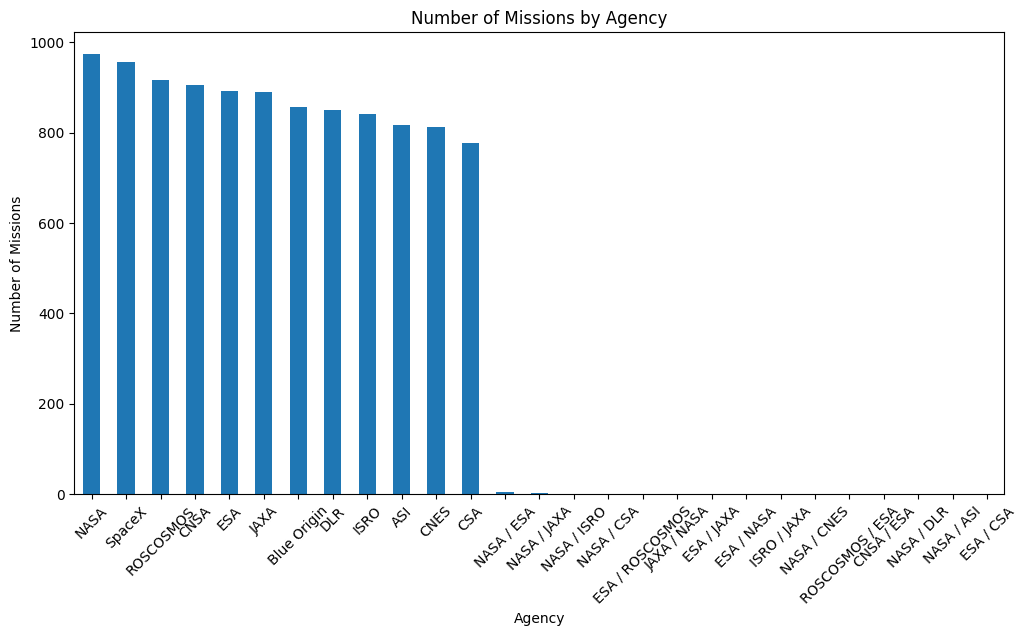


MISSION STATUS DISTRIBUTION
Status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64


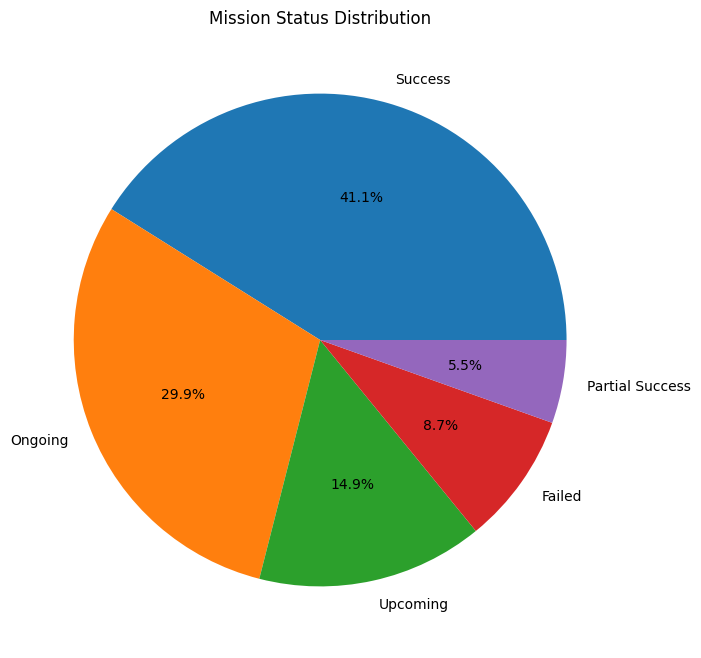


MISSION PHASE DISTRIBUTION
Mission_Phase
Past       6835
Ongoing    2105
Future     1560
Name: count, dtype: int64


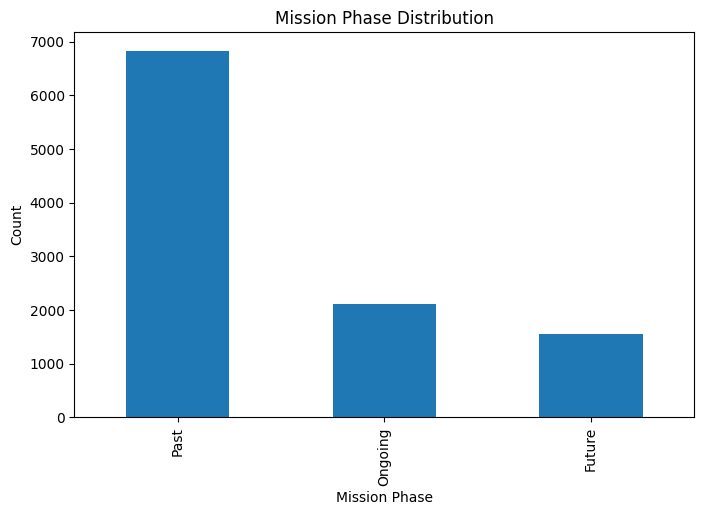


CREW TYPE ANALYSIS
Crew_Type
Uncrewed    7863
Crewed      2637
Name: count, dtype: int64


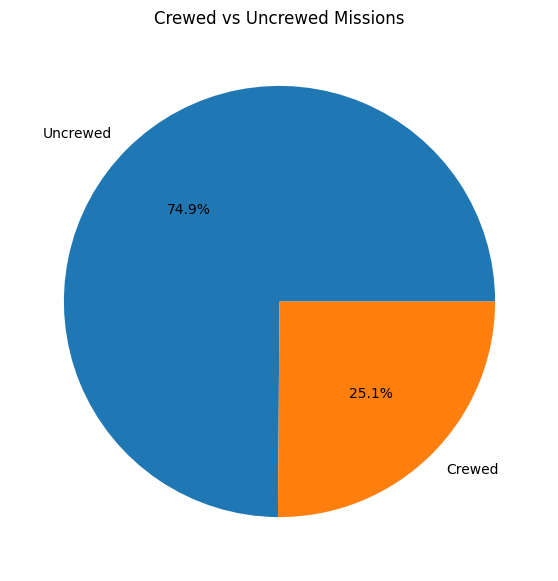


TOP MISSION CATEGORIES
Mission_Category
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Crewed Spaceflight         559
CubeSat                    559
Telescope                  559
Name: count, dtype: int64


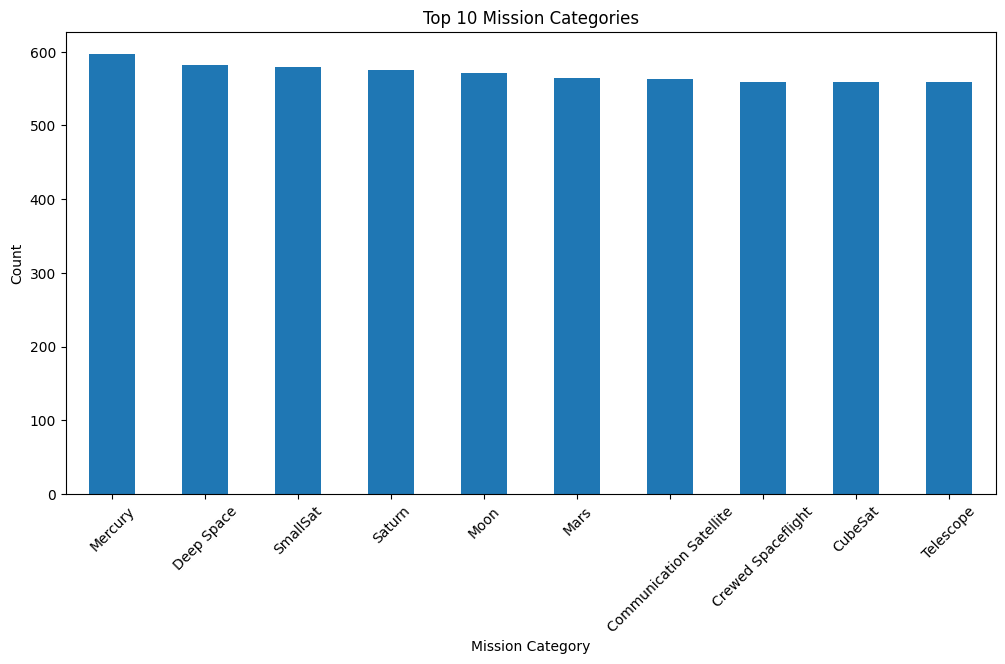


TOTAL ESTIMATED MISSION COST
77529660.9 Million USD


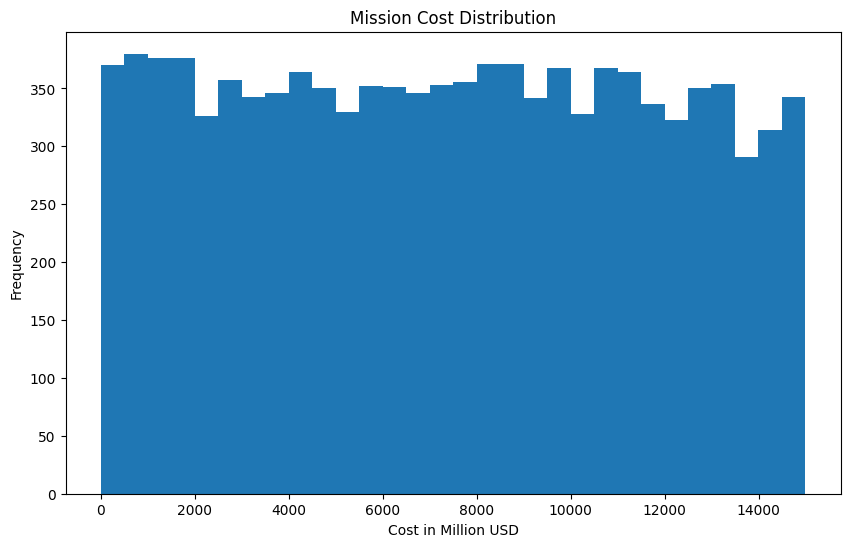


MISSIONS PER YEAR
Launch_Year
1957    103
1958    106
1959     95
1960     90
1961     93
       ... 
2031    151
2032    160
2033    157
2034    146
2035    172
Name: count, Length: 79, dtype: int64


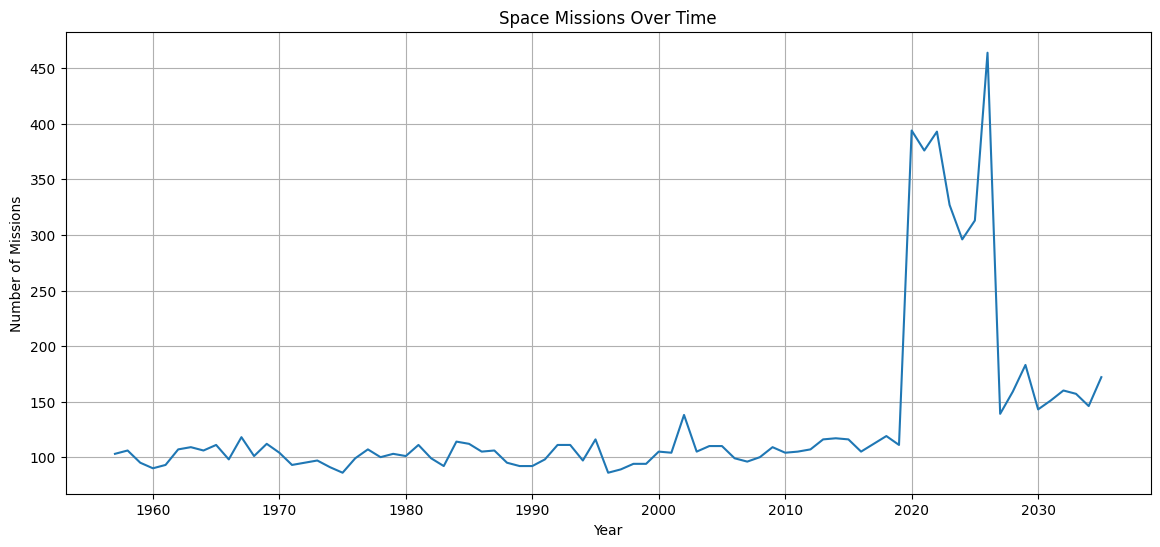


GOVERNMENT VS PRIVATE MISSIONS
Agency_Type
Government    8689
Private       1811
Name: count, dtype: int64


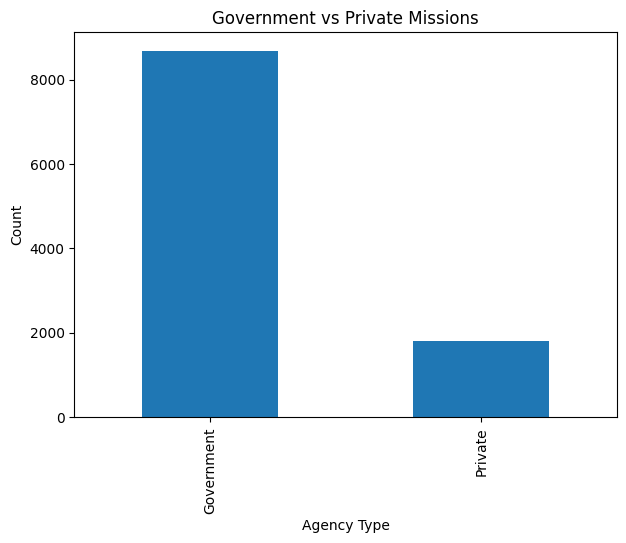


MISSION SUCCESS RATE (%)
Status
Success            41.085714
Ongoing            29.942857
Upcoming           14.857143
Failed              8.657143
Partial Success     5.457143
Name: proportion, dtype: float64

TOP MISSION DESTINATIONS
Destination
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Crewed Spaceflight         559
CubeSat                    559
Telescope                  559
Name: count, dtype: int64


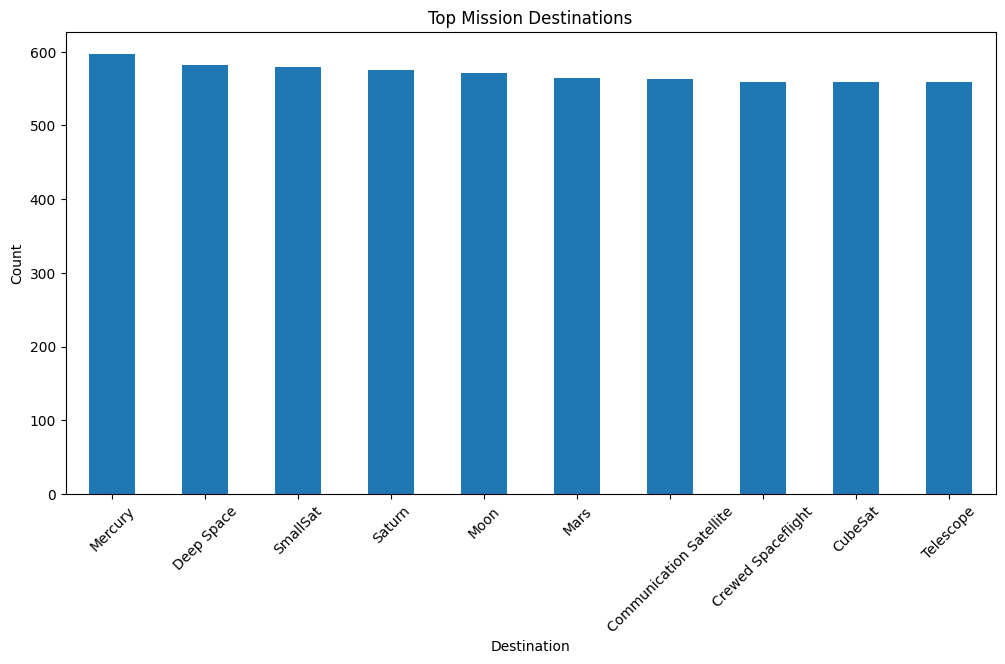


SPACE MISSIONS DATA ANALYSIS COMPLETED


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("Space_Missions_Dataset.csv")

# Display Basic Information
print("\nFIRST FIVE ROWS OF DATASET")
print(df.head())

print("\nDATASET INFORMATION")
print(df.info())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nMISSING VALUES")
print(df.isnull().sum())

# Data Cleaning

# Replace N/A values with NaN
df.replace("N/A", np.nan, inplace=True)

# Convert Launch_Date column into datetime format
df['Launch_Date'] = pd.to_datetime(df['Launch_Date'])

# Convert Cost column into numeric datatype
df['Cost_USD_Million'] = pd.to_numeric(
    df['Cost_USD_Million'],
    errors='coerce'
)

print("\nDATASET INFORMATION AFTER CLEANING")
print(df.info())

# Statistical Summary
print("\nSTATISTICAL SUMMARY")
print(df.describe())

# Analysis 1 : Missions by Agency

agency_count = df['Agency'].value_counts()

print("\nMISSIONS BY AGENCY")
print(agency_count)

plt.figure(figsize=(12, 6))
agency_count.plot(kind='bar')

plt.title("Number of Missions by Agency")
plt.xlabel("Agency")
plt.ylabel("Number of Missions")
plt.xticks(rotation=45)

plt.show()

# Analysis 2 : Mission Status Distribution

status_count = df['Status'].value_counts()

print("\nMISSION STATUS DISTRIBUTION")
print(status_count)

plt.figure(figsize=(8, 8))
status_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Mission Status Distribution")
plt.ylabel("")

plt.show()

# Analysis 3 : Mission Phase Distribution

phase_count = df['Mission_Phase'].value_counts()

print("\nMISSION PHASE DISTRIBUTION")
print(phase_count)

plt.figure(figsize=(8, 5))
phase_count.plot(kind='bar')

plt.title("Mission Phase Distribution")
plt.xlabel("Mission Phase")
plt.ylabel("Count")

plt.show()

# Analysis 4 : Crew Type Analysis

crew_count = df['Crew_Type'].value_counts()

print("\nCREW TYPE ANALYSIS")
print(crew_count)

plt.figure(figsize=(7, 7))
crew_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Crewed vs Uncrewed Missions")
plt.ylabel("")

plt.show()

# Analysis 5 : Top Mission Categories

category_count = (
    df['Mission_Category']
    .value_counts()
    .head(10)
)

print("\nTOP MISSION CATEGORIES")
print(category_count)

plt.figure(figsize=(12, 6))
category_count.plot(kind='bar')

plt.title("Top 10 Mission Categories")
plt.xlabel("Mission Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Analysis 6 : Cost Analysis

total_cost = df['Cost_USD_Million'].sum()

print("\nTOTAL ESTIMATED MISSION COST")
print(total_cost, "Million USD")

plt.figure(figsize=(10, 6))

plt.hist(
    df['Cost_USD_Million'].dropna(),
    bins=30
)

plt.title("Mission Cost Distribution")
plt.xlabel("Cost in Million USD")
plt.ylabel("Frequency")

plt.show()

# Analysis 7 : Missions Over Time

# Extract launch year
df['Launch_Year'] = df['Launch_Date'].dt.year

yearly_launches = (
    df['Launch_Year']
    .value_counts()
    .sort_index()
)

print("\nMISSIONS PER YEAR")
print(yearly_launches)

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_launches.index,
    yearly_launches.values
)

plt.title("Space Missions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Missions")

plt.grid(True)

plt.show()

# Analysis 8 : Government vs Private Missions

agency_type_count = df['Agency_Type'].value_counts()

print("\nGOVERNMENT VS PRIVATE MISSIONS")
print(agency_type_count)

plt.figure(figsize=(7, 5))
agency_type_count.plot(kind='bar')

plt.title("Government vs Private Missions")
plt.xlabel("Agency Type")
plt.ylabel("Count")

plt.show()

# Analysis 9 : Mission Success Rate

success_rate = (
    df['Status']
    .value_counts(normalize=True) * 100
)

print("\nMISSION SUCCESS RATE (%)")
print(success_rate)

# Analysis 10 : Top Destinations

destination_count = (
    df['Destination']
    .value_counts()
    .head(10)
)

print("\nTOP MISSION DESTINATIONS")
print(destination_count)

plt.figure(figsize=(12, 6))
destination_count.plot(kind='bar')

plt.title("Top Mission Destinations")
plt.xlabel("Destination")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

print("\nSPACE MISSIONS DATA ANALYSIS COMPLETED")